## 1. Загрузка данных и вывод информации о них

In [110]:
import pandas as pd
# Читаем файл из папки data 
df = pd.read_csv('data/heart.csv')
# Выводим таблицу на экран
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 2. Проверка данных на наличие пропусков

In [111]:
# находим все пустые значения (isnull) и суммируем их количество по столбцам (sum)
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 3. Преообразование данных о поле в более читаемый формат и применение к ним One-Hot Encoding  

In [112]:
# 1. Сначала преобразуем цифры в читаемые категории
# Используем словарь, где 0 - female, 1 - male
df['sex'] = df['sex'].map({0: 'female', 1: 'male'})

# 2. Применяем One-Hot Encoding
# Это удалит колонку 'sex' и создаст 'sex_female' и 'sex_male'
df = pd.get_dummies(df, columns=['sex'], prefix='sex')

# 3. Важный шаг для нейросети: переводим True/False в 1 и 0
df[['sex_female', 'sex_male']] = df[['sex_female', 'sex_male']].astype(int)

# Проверяем результат
df.head()

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_female,sex_male
0,63,3,145,233,1,0,150,0,2.3,0,0,1,1,0,1
1,37,2,130,250,0,1,187,0,3.5,0,0,2,1,0,1
2,41,1,130,204,0,0,172,0,1.4,2,0,2,1,1,0
3,56,1,120,236,0,1,178,0,0.8,2,0,2,1,0,1
4,57,0,120,354,0,1,163,1,0.6,2,0,2,1,1,0


## 4. Построение диаграмм

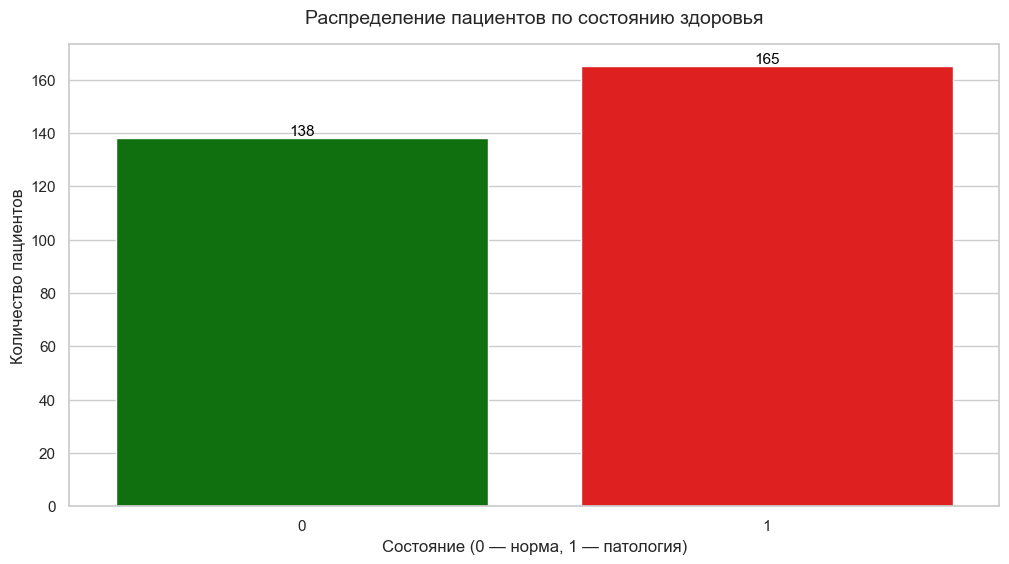

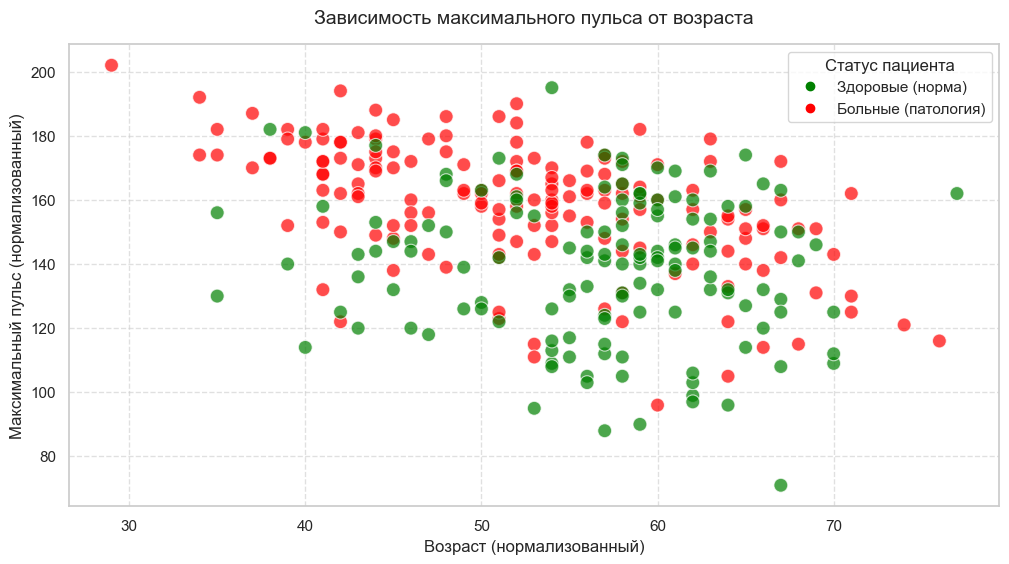

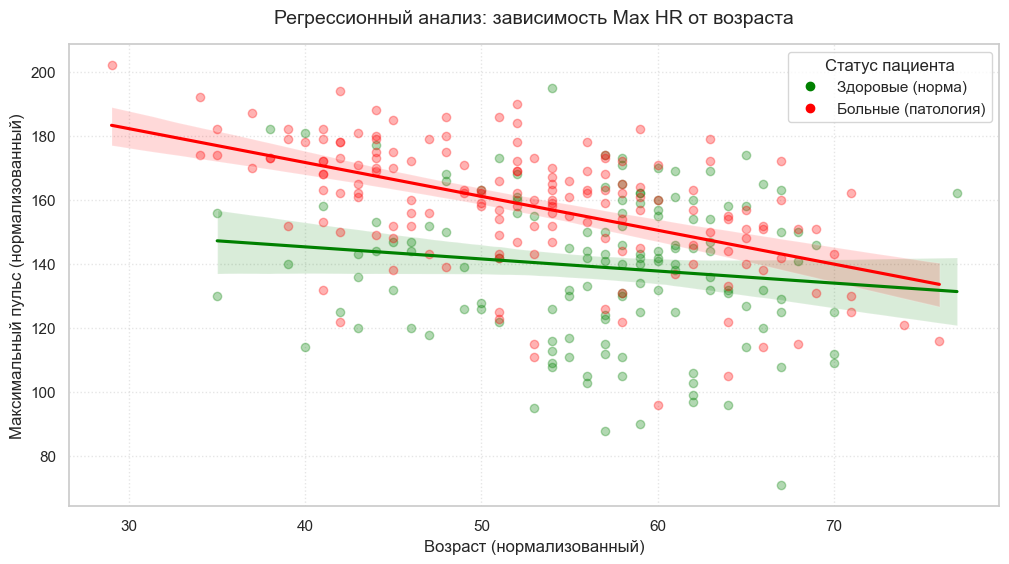

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 0. Настройка темы и общей палитры
sns.set_theme(style="whitegrid")
my_colors = {0: "green", 1: "red"}
custom_legend = [
    mlines.Line2D([], [], color='green', marker='o', linestyle='None', label='Здоровые (норма)'),
    mlines.Line2D([], [], color='red', marker='o', linestyle='None', label='Больные (патология)')
]

# --- ГРАФИК №1: Распределение (Countplot) ---
plt.figure(figsize=(12, 6)) # ТОТ ЖЕ РАЗМЕР
ax = sns.countplot(x='target', data=df, hue='target', palette=my_colors, legend=False)

plt.title('Распределение пациентов по состоянию здоровья', fontsize=14, pad=15)
plt.xlabel('Состояние (0 — норма, 1 — патология)', fontsize=12)
plt.ylabel('Количество пациентов', fontsize=12)

# Добавляем цифры над столбцами
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.show()

# --- ГРАФИК №2: Точечная диаграмма (Scatterplot) ---
plt.figure(figsize=(12, 6)) # ТОТ ЖЕ РАЗМЕР
sns.scatterplot(x='age', y='thalach', hue='target', data=df, 
                palette=my_colors, hue_order=[0, 1], s=100, alpha=0.7, legend=False)

plt.title('Зависимость максимального пульса от возраста', fontsize=14, pad=15)
plt.xlabel('Возраст (нормализованный)', fontsize=12)
plt.ylabel('Максимальный пульс (нормализованный)', fontsize=12)
plt.legend(handles=custom_legend, title='Статус пациента', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- ГРАФИК №3: Регрессия (Regplot) ---
plt.figure(figsize=(12, 6)) # ТОТ ЖЕ РАЗМЕР
sns.regplot(x='age', y='thalach', data=df[df['target'] == 0], color='green', scatter_kws={'alpha':0.3})
sns.regplot(x='age', y='thalach', data=df[df['target'] == 1], color='red', scatter_kws={'alpha':0.3})

plt.title('Регрессионный анализ: зависимость Max HR от возраста', fontsize=14, pad=15)
plt.xlabel('Возраст (нормализованный)', fontsize=12)
plt.ylabel('Максимальный пульс (нормализованный)', fontsize=12)
plt.legend(handles=custom_legend, title='Статус пациента', loc='upper right')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()






## 5. Расчет среднего уровня холестерина для больных и здоровых пациентов

In [114]:
# Группируем по target и считаем среднее для chol
chol_means = df.groupby('target')['chol'].mean()

print("Средний уровень холестерина:")
print(f"Здоровые (0): {chol_means[0]:.2f}")
print(f"Больные (1): {chol_means[1]:.2f}")

Средний уровень холестерина:
Здоровые (0): 251.09
Больные (1): 242.23


## 6. Выполнение нормализации признаков age, trestbps, chol и thalach.

In [115]:
from sklearn.preprocessing import MinMaxScaler

# 1. Создаем объект нормализатора
scaler = MinMaxScaler()

# 2. Список признаков, которые нужно нормализовать
cols_to_norm = ['age', 'trestbps', 'chol', 'thalach']

# 3. Применяем нормализацию
# fit_transform обучается на данных и сразу их преобразует
df[cols_to_norm] = scaler.fit_transform(df[cols_to_norm])

# Проверяем результат (значения должны быть от 0 до 1)
print("Данные после нормализации:")
display(df[cols_to_norm].head())

Данные после нормализации:


,age,trestbps,chol,thalach
0,0.708333,0.481132,0.244292,0.603053
1,0.166667,0.339623,0.283105,0.885496
2,0.250000,0.339623,0.178082,0.770992
3,0.562500,0.245283,0.251142,0.816794
4,0.583333,0.245283,0.520548,0.702290
